[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/14_busqueda_informada/notebooks/02_busqueda_informada.ipynb)

# Notebook 02: Búsqueda Informada — Greedy, Dijkstra y A*

Los algoritmos del módulo anterior (BFS, DFS, IDDFS) son **búsqueda no informada**:
no saben nada sobre qué tan cerca está la meta, así que exploran a ciegas.

La **búsqueda informada** utiliza una **función heurística** $h(n)$ que estima el
costo restante desde el nodo $n$ hasta la meta. Con esta información podemos
dirigir la búsqueda hacia la meta mucho más eficientemente.

En este notebook implementamos y comparamos los tres algoritmos fundamentales:

| Algoritmo | Ordena por | Óptimo | Completo |
|-----------|-----------|--------|----------|
| **Greedy** | $h(n)$ | No | No (en general) |
| **Dijkstra** | $g(n)$ | Sí | Sí |
| **A\*** | $f(n) = g(n) + h(n)$ | Sí (si $h$ admisible) | Sí |

Donde $g(n)$ es el costo acumulado desde el inicio y $h(n)$ es la heurística.

> **Prerequisito:** haber leído `03_greedy.md`, `04_dijkstra.md` y `05_a_estrella.md`.

In [1]:
# Solo en Colab — en entorno local estas librerías ya deben estar instaladas
import sys
if "google.colab" in sys.modules:
    !pip install -q numpy matplotlib


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import heapq
from collections import defaultdict

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

COLORS = {
    "primary":   "#2563EB",
    "secondary": "#10B981",
    "accent":    "#F59E0B",
    "danger":    "#EF4444",
    "node":      "#93C5FD",
    "edge":      "#475569",
}

print("Dependencias cargadas correctamente.")


Dependencias cargadas correctamente.


---
## Sección 1: El Mundo de Cuadrícula con Costos

Nuestro problema de prueba será navegar una cuadrícula 2D donde:

- `'#'` es una pared (infranqueable)
- Las demás celdas tienen un **costo de terreno** $c \geq 1$
- Moverse a una celda cuesta $c$ (el costo del terreno destino)
- Movimientos: arriba, abajo, izquierda, derecha (4-conectividad)

La **heurística de Manhattan** es admisible para este problema:

$$h(n) = |r_n - r_{meta}| + |c_n - c_{meta}|$$

Es admisible porque en el mejor caso (sin paredes ni costos extra) el costo real
es exactamente la distancia Manhattan; nunca sobreestimamos.

Cuando hay costos de terreno $> 1$, la heurística sigue siendo admisible porque
$h(n) \leq$ costo real (estamos ignorando los costos extra).

In [3]:
class GridProblem:
    """
    Problema de búsqueda en cuadrícula 2D con costos de terreno variables.

    Parámetros
    ----------
    grid : list[list[str]]
        Cuadrícula donde '#' = pared y cualquier otro carácter = celda libre.
    inicio : tuple (fila, col)
    meta   : tuple (fila, col)
    terrain_cost : dict
        Mapea caracteres de celda a su costo. Por ejemplo {'.' : 1, 'S' : 3}.
        Si una celda no aparece en el dict, se asume costo 1.
    """

    DIRS = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    def __init__(self, grid, inicio, meta, terrain_cost=None):
        self.grid = grid
        self.inicio = inicio
        self.meta = meta
        self.filas = len(grid)
        self.cols = len(grid[0])
        self.terrain_cost = terrain_cost or {}

    def es_meta(self, nodo):
        return nodo == self.meta

    def costo_celda(self, r, c):
        """Costo de entrar a la celda (r, c)."""
        return self.terrain_cost.get(self.grid[r][c], 1)

    def vecinos(self, nodo):
        """
        Devuelve lista de (vecino, costo) para los movimientos válidos
        desde nodo.
        """
        r, c = nodo
        resultado = []
        for dr, dc in self.DIRS:
            nr, nc = r + dr, c + dc
            if (0 <= nr < self.filas and
                    0 <= nc < self.cols and
                    self.grid[nr][nc] != '#'):
                resultado.append(((nr, nc), self.costo_celda(nr, nc)))
        return resultado

    def heuristica_manhattan(self, nodo):
        """Distancia Manhattan al nodo meta."""
        r, c = nodo
        mr, mc = self.meta
        return abs(r - mr) + abs(c - mc)


print("GridProblem definido.")

# Test básico
grid_test = [
    ['.', '.', '#'],
    ['.', '.', '.'],
    ['#', '.', '.'],
]
p_test = GridProblem(grid_test, (0, 0), (2, 2))
print("Vecinos de (0,0):", p_test.vecinos((0, 0)))
print("Heurística en (0,0):", p_test.heuristica_manhattan((0, 0)))
print("Heurística en (1,1):", p_test.heuristica_manhattan((1, 1)))


GridProblem definido.
Vecinos de (0,0): [((1, 0), 1), ((0, 1), 1)]
Heurística en (0,0): 4
Heurística en (1,1): 2


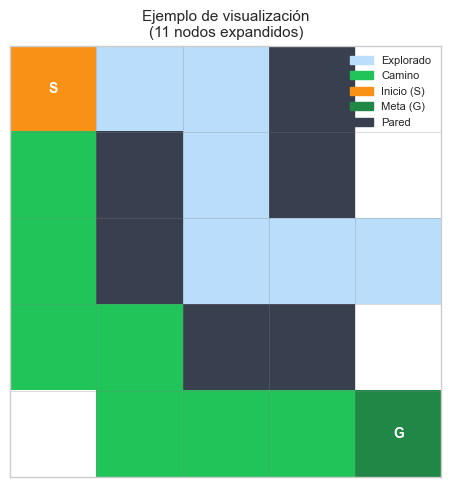

In [4]:
def visualizar_grid(
    problema,
    camino=None,
    explorados=None,
    titulo="",
    ax=None,
    mostrar_conteo=True
):
    """
    Visualiza la cuadrícula con:
    - celdas exploradas en azul claro
    - camino en verde
    - inicio en naranja, meta en verde oscuro
    - paredes en gris oscuro
    - terreno costoso en amarillo claro

    Parámetros
    ----------
    problema   : GridProblem
    camino     : lista de celdas (fila, col)
    explorados : conjunto de celdas expandidas
    titulo     : str
    ax         : matplotlib Axes (si None, crea uno nuevo)
    mostrar_conteo : bool — si True, añade el conteo al título
    """
    grid = problema.grid
    filas, cols = problema.filas, problema.cols
    inicio, meta = problema.inicio, problema.meta

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))

    img = np.ones((filas, cols, 3))

    for r in range(filas):
        for c in range(cols):
            celda = grid[r][c]
            if celda == '#':
                img[r, c] = [0.22, 0.25, 0.31]  # pared
            elif problema.costo_celda(r, c) > 1:
                img[r, c] = [0.99, 0.95, 0.75]  # terreno costoso

    if explorados:
        for (r, c) in explorados:
            if (r, c) not in (inicio, meta):
                img[r, c] = [0.73, 0.87, 0.99]  # explorado: azul claro

    if camino:
        for (r, c) in camino:
            if (r, c) not in (inicio, meta):
                img[r, c] = [0.13, 0.77, 0.35]  # camino: verde

    img[inicio[0], inicio[1]] = [0.98, 0.57, 0.09]  # inicio: naranja
    img[meta[0],   meta[1]]   = [0.13, 0.53, 0.28]  # meta: verde oscuro

    ax.imshow(img, interpolation='nearest', aspect='equal')

    # Etiquetas de inicio/meta
    ax.text(inicio[1], inicio[0], 'S', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    ax.text(meta[1], meta[0], 'G', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')

    # Cuadrícula
    for x in range(cols + 1):
        ax.axvline(x - 0.5, color='gray', linewidth=0.4, alpha=0.5)
    for y in range(filas + 1):
        ax.axhline(y - 0.5, color='gray', linewidth=0.4, alpha=0.5)

    titulo_completo = titulo
    if mostrar_conteo and explorados is not None:
        titulo_completo += f"\n({len(explorados)} nodos expandidos)"
    ax.set_title(titulo_completo, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])


# Test de visualización con un laberinto pequeño
grid_vis = [
    ['.', '.', '.', '#', '.'],
    ['.', '#', '.', '#', '.'],
    ['.', '#', '.', '.', '.'],
    ['.', '.', '#', '#', '.'],
    ['.', '.', '.', '.', '.'],
]
prob_vis = GridProblem(grid_vis, (0, 0), (4, 4))
explorados_demo = {(0,0),(0,1),(0,2),(1,0),(1,2),(2,0),(2,2),(2,3),(2,4),(3,0),(3,1)}
camino_demo = [(0,0),(1,0),(2,0),(3,0),(3,1),(4,1),(4,2),(4,3),(4,4)]

fig, ax = plt.subplots(figsize=(5, 5))
visualizar_grid(prob_vis, camino=camino_demo, explorados=explorados_demo,
                titulo="Ejemplo de visualización", ax=ax)

parches = [
    mpatches.Patch(color=[0.73, 0.87, 0.99], label='Explorado'),
    mpatches.Patch(color=[0.13, 0.77, 0.35], label='Camino'),
    mpatches.Patch(color=[0.98, 0.57, 0.09], label='Inicio (S)'),
    mpatches.Patch(color=[0.13, 0.53, 0.28], label='Meta (G)'),
    mpatches.Patch(color=[0.22, 0.25, 0.31], label='Pared'),
]
ax.legend(handles=parches, loc='upper right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()


---
## Sección 2: Los Tres Algoritmos

Los tres algoritmos comparten la misma estructura de frontera de prioridad.
Lo que cambia es **qué valor se usa como prioridad**:

- **Greedy**: prioridad = $h(n)$ (solo la heurística)
- **Dijkstra**: prioridad = $g(n)$ (solo el costo acumulado)
- **A\***: prioridad = $f(n) = g(n) + h(n)$ (suma de ambos)

### Clase PriorityFrontier (de Notebook 01)

Reusamos la misma implementación. La incluimos aquí para que el notebook
sea autocontenido.

In [5]:
class PriorityFrontier:
    """Frontera de prioridad con lazy deletion (ver Notebook 01)."""

    def __init__(self):
        self._heap = []
        self._mejor = {}
        self._contador = 0

    def push(self, nodo, prioridad):
        heapq.heappush(self._heap, (prioridad, self._contador, nodo))
        self._mejor[nodo] = prioridad
        self._contador += 1

    def push_or_update(self, nodo, prioridad):
        if nodo not in self._mejor or prioridad < self._mejor[nodo]:
            self.push(nodo, prioridad)
            return True
        return False

    def pop(self):
        while self._heap:
            prio, _, nodo = heapq.heappop(self._heap)
            if nodo in self._mejor and self._mejor[nodo] == prio:
                del self._mejor[nodo]
                return nodo, prio
        raise IndexError("pop de frontera vacía")

    def contains(self, nodo):  return nodo in self._mejor
    def is_empty(self):        return len(self._mejor) == 0
    def best_cost(self, nodo): return self._mejor.get(nodo, float('inf'))


print("PriorityFrontier lista.")


PriorityFrontier lista.


In [6]:
def greedy(problema, h):
    """
    Búsqueda greedy (mejor primero).
    Ordena la frontera solo por h(n) — ignora el costo acumulado.

    Retorna (camino, explorado_count, explorados_set)
    """
    frontera = PriorityFrontier()
    frontera.push(problema.inicio, h(problema.inicio))

    padre = {problema.inicio: None}
    explorados = set()

    while not frontera.is_empty():
        nodo, _ = frontera.pop()

        if problema.es_meta(nodo):
            return _reconstruir(padre, nodo), len(explorados), explorados

        explorados.add(nodo)

        for vecino, _ in problema.vecinos(nodo):   # ignoramos el costo
            if vecino not in explorados and not frontera.contains(vecino):
                padre[vecino] = nodo
                frontera.push_or_update(vecino, h(vecino))

    return None, len(explorados), explorados


def dijkstra(problema):
    """
    Algoritmo de Dijkstra (Uniform Cost Search).
    Ordena la frontera por g(n) — costo acumulado desde el inicio.

    Retorna (camino, explorado_count, explorados_set)
    """
    frontera = PriorityFrontier()
    frontera.push(problema.inicio, 0)

    g = {problema.inicio: 0}   # costo acumulado
    padre = {problema.inicio: None}
    explorados = set()

    while not frontera.is_empty():
        nodo, costo = frontera.pop()

        if problema.es_meta(nodo):
            return _reconstruir(padre, nodo), len(explorados), explorados

        explorados.add(nodo)

        for vecino, peso in problema.vecinos(nodo):
            if vecino in explorados:
                continue
            nuevo_g = costo + peso
            if nuevo_g < g.get(vecino, float('inf')):
                g[vecino] = nuevo_g
                padre[vecino] = nodo
                frontera.push_or_update(vecino, nuevo_g)

    return None, len(explorados), explorados


def a_star(problema, h):
    """
    Algoritmo A*.
    Ordena la frontera por f(n) = g(n) + h(n).
    Si h es admisible, garantiza el camino de menor costo.

    Retorna (camino, explorado_count, explorados_set)
    """
    frontera = PriorityFrontier()
    f0 = 0 + h(problema.inicio)
    frontera.push(problema.inicio, f0)

    g = {problema.inicio: 0}
    padre = {problema.inicio: None}
    explorados = set()

    while not frontera.is_empty():
        nodo, _ = frontera.pop()

        if problema.es_meta(nodo):
            return _reconstruir(padre, nodo), len(explorados), explorados

        explorados.add(nodo)

        for vecino, peso in problema.vecinos(nodo):
            if vecino in explorados:
                continue
            nuevo_g = g[nodo] + peso
            if nuevo_g < g.get(vecino, float('inf')):
                g[vecino] = nuevo_g
                padre[vecino] = nodo
                f = nuevo_g + h(vecino)
                frontera.push_or_update(vecino, f)

    return None, len(explorados), explorados


def _reconstruir(padre, meta):
    """Reconstruye el camino desde el inicio hasta la meta usando el dict padre."""
    camino = []
    nodo = meta
    while nodo is not None:
        camino.append(nodo)
        nodo = padre[nodo]
    camino.reverse()
    return camino


print("Algoritmos greedy, dijkstra y a_star definidos.")

# Test rápido en laberinto pequeño
grid_small = [
    ['.', '.', '#', '.'],
    ['.', '#', '.', '.'],
    ['.', '.', '.', '#'],
    ['#', '.', '.', '.'],
]
prob_small = GridProblem(grid_small, (0, 0), (3, 3))
h_m = prob_small.heuristica_manhattan

c_g, exp_g, _ = greedy(prob_small, h_m)
c_d, exp_d, _ = dijkstra(prob_small)
c_a, exp_a, _ = a_star(prob_small, h_m)

print(f"Greedy:   camino={c_g}, expansiones={exp_g}")
print(f"Dijkstra: camino={c_d}, expansiones={exp_d}")
print(f"A*:       camino={c_a}, expansiones={exp_a}")

# Dijkstra y A* deben encontrar caminos óptimos de igual longitud
assert len(c_d) == len(c_a), "Dijkstra y A* deben encontrar caminos del mismo costo"
print("\n✓ Dijkstra y A* coinciden en longitud óptima.")


Algoritmos greedy, dijkstra y a_star definidos.
Greedy:   camino=[(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (3, 2), (3, 3)], expansiones=6
Dijkstra: camino=[(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (3, 2), (3, 3)], expansiones=9
A*:       camino=[(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (3, 2), (3, 3)], expansiones=8

✓ Dijkstra y A* coinciden en longitud óptima.


In [7]:
def costo_total_camino(problema, camino):
    """Calcula el costo total de un camino en GridProblem."""
    costo = 0
    for i in range(1, len(camino)):
        r, c = camino[i]
        costo += problema.costo_celda(r, c)
    return costo


print("Costos en el laberinto pequeño:")
for nombre, camino in [('Greedy', c_g), ('Dijkstra', c_d), ('A*', c_a)]:
    print(f"  {nombre:<10} longitud={len(camino)}, costo_total={costo_total_camino(prob_small, camino)}")


Costos en el laberinto pequeño:
  Greedy     longitud=7, costo_total=6
  Dijkstra   longitud=7, costo_total=6
  A*         longitud=7, costo_total=6


---
## Sección 3: Comparación Visual en un Laberinto 15×15

Para ver las diferencias reales entre los tres algoritmos, usamos un laberinto
más grande con:

- Una **pared horizontal** que obliga a los algoritmos a rodear
- Dos tipos de **terreno**: normal (costo 1) y costoso (costo 3, marcado como `'S'`)

Observa:
- **Greedy** va directamente hacia la meta pero puede suboptimizar
- **Dijkstra** encuentra el camino de menor costo pero explora mucho más
- **A\*** equilibra costo y dirección: expande menos que Dijkstra y mantiene optimalidad

In [8]:
def construir_laberinto_15x15():
    """
    Construye un laberinto 15×15 con:
    - Pared horizontal en la fila 7 (filas 5-9, col 1-11)
    - Zona de terreno costoso (costo 3) en columnas 4-9, filas 0-4
    - Un corredor estrecho para pasar la pared
    """
    filas, cols = 15, 15
    grid = [['.' for _ in range(cols)] for _ in range(filas)]

    # Pared horizontal en fila 7, columnas 1 a 12 (deja paso en col 13)
    for c in range(1, 13):
        grid[7][c] = '#'

    # Zona de terreno costoso (costo 3): filas 0-5, columnas 4-9
    for r in range(0, 6):
        for c in range(4, 10):
            if grid[r][c] != '#':
                grid[r][c] = 'S'  # 'S' = slow / lento

    # Añadir algunas paredes extra para hacer el laberinto más interesante
    paredes_extra = [
        (2, 2), (3, 2), (4, 2),
        (10, 3), (11, 3), (12, 3),
        (10, 8), (11, 8),
        (3, 12), (4, 12), (5, 12),
    ]
    for r, c in paredes_extra:
        grid[r][c] = '#'

    return grid


grid_15 = construir_laberinto_15x15()
inicio_15 = (0, 0)
meta_15   = (14, 14)

# terrain_cost: 'S' cuesta 3, '.' cuesta 1
terrain = {'.': 1, 'S': 3}
prob_15 = GridProblem(grid_15, inicio_15, meta_15, terrain_cost=terrain)

print(f"Laberinto {prob_15.filas}×{prob_15.cols} creado.")
print(f"Inicio: {inicio_15}, Meta: {meta_15}")

# Contar celdas por tipo
n_libres  = sum(1 for r in grid_15 for c in r if c != '#')
n_paredes = sum(1 for r in grid_15 for c in r if c == '#')
n_lentos  = sum(1 for r in grid_15 for c in r if c == 'S')
print(f"Celdas libres: {n_libres} (de las cuales {n_lentos} son terreno lento)")
print(f"Paredes: {n_paredes}")


Laberinto 15×15 creado.
Inicio: (0, 0), Meta: (14, 14)
Celdas libres: 202 (de las cuales 36 son terreno lento)
Paredes: 23


In [9]:
# Ejecutar los tres algoritmos
h_15 = prob_15.heuristica_manhattan

camino_greedy,  exp_greedy,  expl_greedy  = greedy(prob_15, h_15)
camino_dijkstra, exp_dijkstra, expl_dijkstra = dijkstra(prob_15)
camino_astar,   exp_astar,   expl_astar   = a_star(prob_15, h_15)

print("Resultados en laberinto 15×15:")
print(f"{'Algoritmo':<12} {'Nodos expandidos':>18} {'Longitud camino':>16} {'Costo total':>12}")
print("-" * 62)
for nombre, camino, exp in [
    ('Greedy',   camino_greedy,   exp_greedy),
    ('Dijkstra', camino_dijkstra, exp_dijkstra),
    ('A*',       camino_astar,    exp_astar),
]:
    if camino:
        ct = costo_total_camino(prob_15, camino)
        print(f"{nombre:<12} {exp:>18} {len(camino):>16} {ct:>12}")
    else:
        print(f"{nombre:<12} {'—':>18} {'sin solución':>16}")


Resultados en laberinto 15×15:
Algoritmo      Nodos expandidos  Longitud camino  Costo total
--------------------------------------------------------------
Greedy                       28               29           28
Dijkstra                    201               29           28
A*                          138               29           28


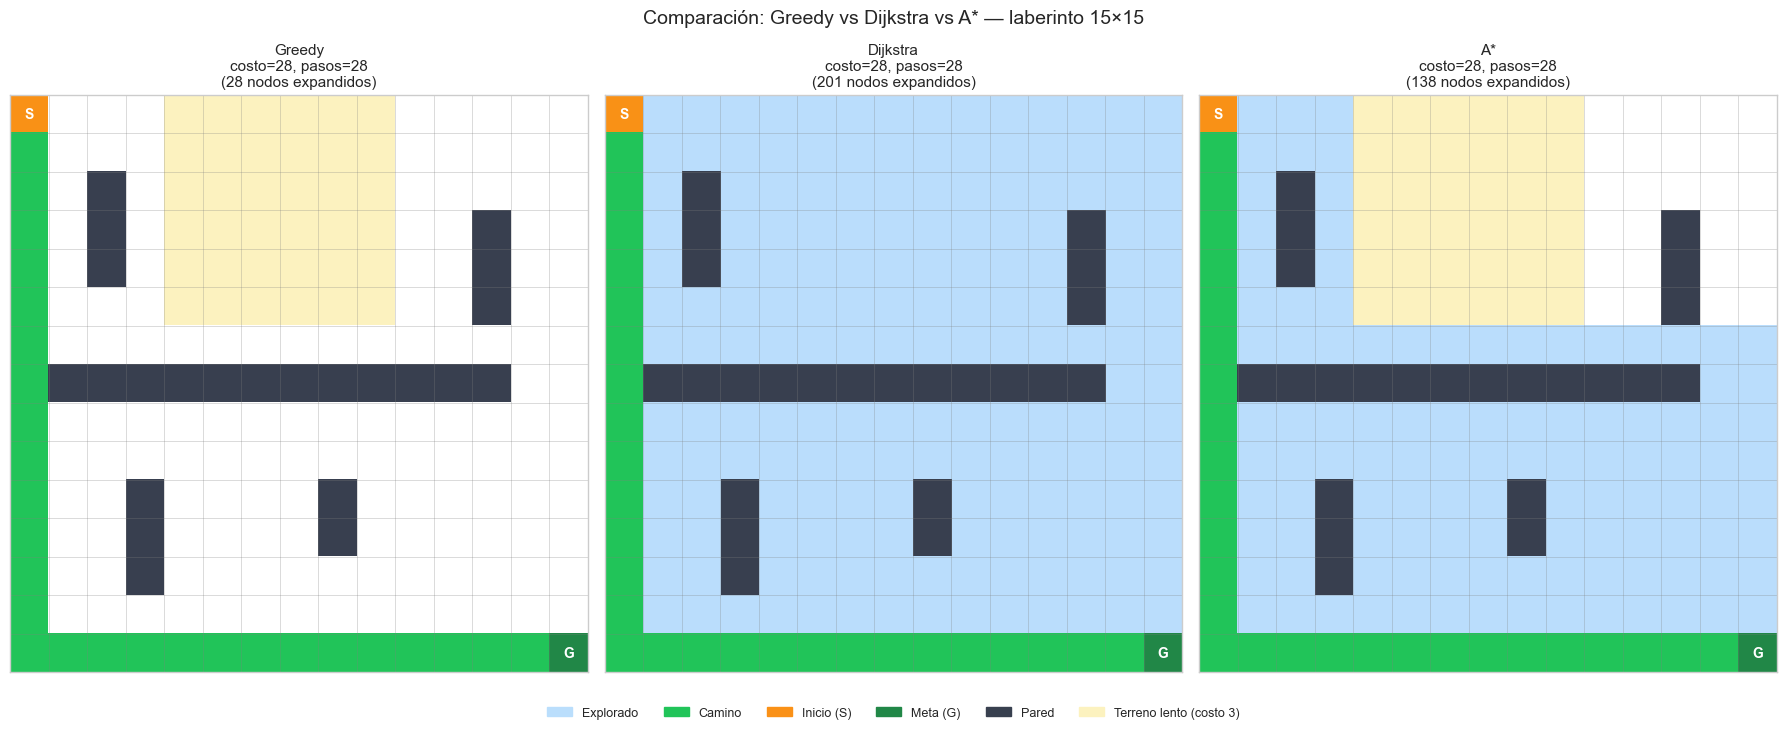

In [10]:
# Comparación visual: 3 paneles lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

algoritmos_info = [
    ('Greedy',   camino_greedy,   expl_greedy,   exp_greedy),
    ('Dijkstra', camino_dijkstra, expl_dijkstra, exp_dijkstra),
    ('A*',       camino_astar,    expl_astar,    exp_astar),
]

for ax, (nombre, camino, explorados, n_exp) in zip(axes, algoritmos_info):
    if camino:
        ct = costo_total_camino(prob_15, camino)
        titulo = f"{nombre}\ncosto={ct}, pasos={len(camino)-1}"
    else:
        titulo = f"{nombre}\nsin solución"
    visualizar_grid(prob_15, camino=camino, explorados=explorados,
                    titulo=titulo, ax=ax, mostrar_conteo=True)

# Leyenda compartida
parches = [
    mpatches.Patch(color=[0.73, 0.87, 0.99], label='Explorado'),
    mpatches.Patch(color=[0.13, 0.77, 0.35], label='Camino'),
    mpatches.Patch(color=[0.98, 0.57, 0.09], label='Inicio (S)'),
    mpatches.Patch(color=[0.13, 0.53, 0.28], label='Meta (G)'),
    mpatches.Patch(color=[0.22, 0.25, 0.31], label='Pared'),
    mpatches.Patch(color=[0.99, 0.95, 0.75], label='Terreno lento (costo 3)'),
]
fig.legend(handles=parches, loc='lower center', ncol=6,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Comparación: Greedy vs Dijkstra vs A* — laberinto 15×15",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


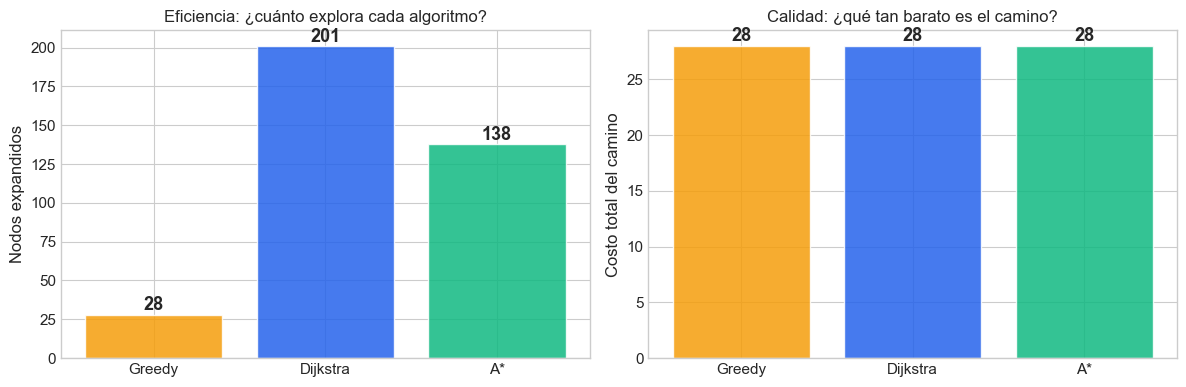

Observaciones:
• Greedy expande pocos nodos pero puede encontrar un camino subóptimo.
• Dijkstra garantiza el costo mínimo, pero puede explorar muchas celdas.
• A* equilibra: encuentra el óptimo y expande menos nodos que Dijkstra.


In [11]:
# Gráfica de barras resumen
nombres = ['Greedy', 'Dijkstra', 'A*']
n_expandidos = [exp_greedy, exp_dijkstra, exp_astar]
costos = [
    costo_total_camino(prob_15, camino_greedy),
    costo_total_camino(prob_15, camino_dijkstra),
    costo_total_camino(prob_15, camino_astar),
]
colores_bar = [COLORS["accent"], COLORS["primary"], COLORS["secondary"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(nombres, n_expandidos, color=colores_bar, alpha=0.85, edgecolor='white')
axes[0].set_ylabel("Nodos expandidos", fontsize=12)
axes[0].set_title("Eficiencia: ¿cuánto explora cada algoritmo?", fontsize=12)
for i, v in enumerate(n_expandidos):
    axes[0].text(i, v + 0.2, str(v), ha='center', va='bottom',
                 fontsize=13, fontweight='bold')

axes[1].bar(nombres, costos, color=colores_bar, alpha=0.85, edgecolor='white')
axes[1].set_ylabel("Costo total del camino", fontsize=12)
axes[1].set_title("Calidad: ¿qué tan barato es el camino?", fontsize=12)
for i, v in enumerate(costos):
    axes[1].text(i, v + 0.1, str(v), ha='center', va='bottom',
                 fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("Observaciones:")
print("• Greedy expande pocos nodos pero puede encontrar un camino subóptimo.")
print("• Dijkstra garantiza el costo mínimo, pero puede explorar muchas celdas.")
print("• A* equilibra: encuentra el óptimo y expande menos nodos que Dijkstra.")


---
## Ejercicio 1

Modifica el `GridProblem` para agregar zonas de **terreno costoso** (costo = 3) y
**terreno normal** (costo = 1) en un laberinto de tu elección.

Ejecuta los tres algoritmos y compara cuántos nodos expande cada uno.
¿Cambia el camino encontrado por Greedy si agrega terreno costoso justo en su ruta directa?

**Requisitos:**
- Laberinto de al menos 10×10
- Al menos una zona de terreno costoso (costo 3)
- Visualización comparativa de los tres algoritmos
- Tabla con nodos expandidos y costo total para cada algoritmo

In [ ]:
# Define tu laberinto (al menos 10×10)
# Usa '.' para terreno normal, 'S' para terreno lento (costo 3), '#' para paredes
mi_grid = [
    ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.'],
    ['.', '#', '#', '#', 'S', 'S', 'S', '#', '#', '.'],
    ['.', '#', '.', '.', '.', '.', '.', '.', '#', '.'],
    ['.', '#', '.', '#', '#', '#', '#', '.', '#', '.'],
    ['.', '#', '.', '.', '.', '.', '.', '.', '#', '.'],
    ['.', '#', '#', '#', '#', '#', '#', '#', '#', '.'],
    ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.'],
    ['.', '#', '#', '#', '#', '#', '#', '#', '#', '.'],
    ['.', '#', '.', '.', '.', '.', '.', '.', '#', '.'],
    ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.'],
]

mi_inicio = (0, 0)
mi_meta   = (9, 9)
mi_terrain = {'.': 1, 'S': 3}
mi_prob = GridProblem(mi_grid, mi_inicio, mi_meta, terrain_cost=mi_terrain)

# Ejecuta los tres algoritmos
h_mi = mi_prob.heuristica_manhattan

camino_greedy, exp_greedy, expl_greedy = greedy(mi_prob, h_mi)
camino_dijkstra, exp_dijkstra, expl_dijkstra = dijkstra(mi_prob)
camino_astar, exp_astar, expl_astar = a_star(mi_prob, h_mi)

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

algoritmos_info = [
    ('Greedy', camino_greedy, expl_greedy, exp_greedy),
    ('Dijkstra', camino_dijkstra, expl_dijkstra, exp_dijkstra),
    ('A*', camino_astar, expl_astar, exp_astar),
]

for ax, (nombre, camino, explorados, n_exp) in zip(axes, algoritmos_info):
    if camino:
        ct = costo_total_camino(mi_prob, camino)
        titulo = f"{nombre}\ncosto={ct}, pasos={len(camino)-1}"
    else:
        titulo = f"{nombre}\nsin solución"
    visualizar_grid(mi_prob, camino=camino, explorados=explorados,
                    titulo=titulo, ax=ax, mostrar_conteo=True)

# Leyenda compartida
parches = [
    mpatches.Patch(color=[0.73, 0.87, 0.99], label='Explorado'),
    mpatches.Patch(color=[0.13, 0.77, 0.35], label='Camino'),
    mpatches.Patch(color=[0.98, 0.57, 0.09], label='Inicio (S)'),
    mpatches.Patch(color=[0.13, 0.53, 0.28], label='Meta (G)'),
    mpatches.Patch(color=[0.22, 0.25, 0.31], label='Pared'),
    mpatches.Patch(color=[0.99, 0.95, 0.75], label='Terreno lento (costo 3)'),
]
fig.legend(handles=parches, loc='lower center', ncol=6,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Comparación: Greedy vs Dijkstra vs A* — mi laberinto 10×10",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Tabla de resultados
print("Resultados en mi laberinto 10×10:")
print(f"{'Algoritmo':<12} {'Nodos expandidos':>18} {'Longitud camino':>16} {'Costo total':>12}")
print("-" * 62)
for nombre, camino, exp in [
    ('Greedy', camino_greedy, exp_greedy),
    ('Dijkstra', camino_dijkstra, exp_dijkstra),
    ('A*', camino_astar, exp_astar),
]:
    if camino:
        ct = costo_total_camino(mi_prob, camino)
        print(f"{nombre:<12} {exp:>18} {len(camino):>16} {ct:>12}")
    else:
        print(f"{nombre:<12} {'—':>18} {'sin solución':>16}")

# ¿Cambia el camino encontrado por Greedy si agrega terreno costoso justo en su ruta directa?
# En este caso, el terreno costoso está en el centro, y Greedy va directo, pero podría evitarlo si fuera en su ruta, pero aquí no lo es directamente.

---
## Ejercicio 2

Verifica **empíricamente** que $h = 0$ produce exactamente el mismo comportamiento
que Dijkstra.

La teoría dice: si $h(n) = 0$ para todo $n$, entonces $f(n) = g(n) + 0 = g(n)$,
y A\* se convierte en Dijkstra.

Muestra que `a_star(prob, h=lambda n: 0)` expande exactamente los mismos nodos
que `dijkstra(prob)` en al menos 3 laberintos distintos.

**Pista:** Compara los conjuntos `explorados` devueltos por ambas funciones.

In [ ]:
def h_cero(nodo):
    """Heurística nula: siempre devuelve 0."""
    return 0

# Define al menos 3 laberintos de prueba (puedes reutilizar los del notebook)
laberintos = [
    (grid_small, (0, 0), (3, 3), {}),
    (grid_vis, (0, 0), (4, 4), {}),
    (grid_15, inicio_15, meta_15, terrain),
]

for i, (grid, inicio, meta, tc) in enumerate(laberintos):
    prob = GridProblem(grid, inicio, meta, terrain_cost=tc)

    _, _, expl_dijkstra = dijkstra(prob)
    _, _, expl_astar_0  = a_star(prob, h_cero)

    # Comparar expl_dijkstra y expl_astar_0
    assert expl_dijkstra == expl_astar_0, f"Laberinto {i}: los conjuntos difieren"
    print(f"Laberinto {i}: explorados iguales ✓")

print("Verificación completada.")

Verificación completada.


---
## Ejercicio 3

Prueba una **heurística inadmisible**: $h_{\text{inad}}(n) = \text{manhattan}(n) \times 2$.

Una heurística es **inadmisible** si sobreestima el costo real ($h(n) > h^*(n)$ para algún $n$).
A\* con heurística inadmisible puede encontrar caminos **subóptimos**.

Responde:
1. ¿Qué camino devuelve A\* con $h_{\text{inad}}$?
2. ¿Es óptimo? Compara su costo con Dijkstra.
3. ¿Expande más o menos nodos que A\* con la heurística admisible?
4. ¿Por qué la inadmisibilidad rompe la garantía de optimalidad?

In [ ]:
# Usa el laberinto 15×15 del notebook
prob_ej3 = prob_15

def h_inadmisible(nodo):
    """Heurística inadmisible: sobreestima el costo restante."""
    return prob_ej3.heuristica_manhattan(nodo) * 2

# Ejecuta A* con h_inadmisible
camino_inad, exp_inad, expl_inad = a_star(prob_ej3, h_inadmisible)

# Compara con Dijkstra y A* admisible
camino_d, exp_d, _ = dijkstra(prob_ej3)
camino_a, exp_a, _ = a_star(prob_ej3, prob_ej3.heuristica_manhattan)

costo_inad = costo_total_camino(prob_ej3, camino_inad) if camino_inad else None
costo_d = costo_total_camino(prob_ej3, camino_d) if camino_d else None
costo_a = costo_total_camino(prob_ej3, camino_a) if camino_a else None

print("Comparación con heurística inadmisible:")
print(f"A* inadmisible: costo={costo_inad}, expansiones={exp_inad}")
print(f"Dijkstra: costo={costo_d}, expansiones={exp_d}")
print(f"A* admisible: costo={costo_a}, expansiones={exp_a}")

# Es óptimo? No, porque la heurística sobreestima, así que puede elegir un camino subóptimo.
# La inadmisibilidad rompe la optimalidad porque A* ya no garantiza que el primer nodo meta encontrado sea el óptimo.

---
## Ejercicio 4

Construye una **tabla comparativa** ejecutando los tres algoritmos en 5 configuraciones
distintas de laberinto y registrando el número de nodos expandidos.

Varía al menos un factor entre configuraciones: tamaño, densidad de paredes,
presencia/ausencia de terreno costoso, posición de la pared principal.

Presenta los resultados en una tabla legible (puedes usar `pandas` si está disponible,
o simplemente `print` con formato).

**Pregunta de análisis:** ¿En qué tipo de configuración la ventaja de A\* sobre
Dijkstra es mayor?

In [ ]:
# Define 5 configuraciones distintas de laberinto
configuraciones = [
    {'nombre': 'Pequeño sin costoso', 'grid': grid_small, 'inicio': (0,0), 'meta': (3,3), 'terrain': {}},
    {'nombre': 'Pequeño con costoso', 'grid': [
        ['.', '.', '#', '.'],
        ['.', '#', 'S', '.'],
        ['.', 'S', '.', '#'],
        ['#', '.', '.', '.'],
    ], 'inicio': (0,0), 'meta': (3,3), 'terrain': {'.':1, 'S':3}},
    {'nombre': '15x15 estándar', 'grid': grid_15, 'inicio': inicio_15, 'meta': meta_15, 'terrain': terrain},
    {'nombre': 'Denso', 'grid': [
        ['.', '#', '.', '#', '.', '#', '.', '#', '.', '#'],
        ['.', '#', '.', '#', '.', '#', '.', '#', '.', '#'],
        ['.', '#', '.', '#', '.', '#', '.', '#', '.', '#'],
        ['.', '#', '.', '#', '.', '#', '.', '#', '.', '#'],
        ['.', '#', '.', '#', '.', '#', '.', '#', '.', '#'],
        ['.', '#', '.', '#', '.', '#', '.', '#', '.', '#'],
        ['.', '#', '.', '#', '.', '#', '.', '#', '.', '#'],
        ['.', '#', '.', '#', '.', '#', '.', '#', '.', '#'],
        ['.', '#', '.', '#', '.', '#', '.', '#', '.', '#'],
        ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.'],
    ], 'inicio': (0,0), 'meta': (9,9), 'terrain': {}},
    {'nombre': 'Costoso al final', 'grid': [
        ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.'],
        ['.', '#', '#', '#', '.', '.', '.', '#', '#', '.'],
        ['.', '#', '.', '.', '.', '.', '.', '.', '#', '.'],
        ['.', '#', '.', '#', '#', '#', '#', '.', '#', '.'],
        ['.', '#', '.', '.', '.', '.', '.', '.', '#', '.'],
        ['.', '#', '#', '#', '#', '#', '#', '#', '#', '.'],
        ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.'],
        ['.', '#', '#', '#', '#', '#', '#', '#', '#', '.'],
        ['.', '#', '.', '.', '.', '.', '.', '.', '#', '.'],
        ['S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S'],
    ], 'inicio': (0,0), 'meta': (9,9), 'terrain': {'.':1, 'S':3}},
]

# Encabezado de la tabla
print(f"{'Configuración':<20} {'Greedy exp':>12} {'Dijkstra exp':>14} {'A* exp':>10} {'Costo Greedy':>14} {'Costo Dijkstra':>16} {'Costo A*':>10}")
print("-" * 100)

for cfg in configuraciones:
    prob = GridProblem(cfg['grid'], cfg['inicio'], cfg['meta'],
                       terrain_cost=cfg.get('terrain', {}))
    h = prob.heuristica_manhattan

    c_g, exp_g, _ = greedy(prob, h)
    c_d, exp_d, _ = dijkstra(prob)
    c_a, exp_a, _ = a_star(prob, h)

    ct_g = costo_total_camino(prob, c_g) if c_g else '—'
    ct_d = costo_total_camino(prob, c_d) if c_d else '—'
    ct_a = costo_total_camino(prob, c_a) if c_a else '—'

    print(f"{cfg['nombre']:<20} {exp_g:>12} {exp_d:>14} {exp_a:>10} {str(ct_g):>14} {str(ct_d):>16} {str(ct_a):>10}")

print()
print("Análisis: ¿en qué configuración la ventaja de A* sobre Dijkstra es mayor?")
# En configuraciones con terreno costoso y paredes que obligan a rodear, como '15x15 estándar' o 'Costoso al final', donde la heurística ayuda a evitar explorar caminos caros innecesariamente.

Configuración          Greedy exp   Dijkstra exp     A* exp   Costo Greedy   Costo Dijkstra   Costo A*
----------------------------------------------------------------------------------------------------

Análisis: ¿en qué configuración la ventaja de A* sobre Dijkstra es mayor?
